In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
data = pd.read_json("../results/bm_auto_regressive_cpu_2.json")

print(data["device_count"].value_counts())

data

device_count
1    1000
2    1000
4    1000
Name: count, dtype: int64


,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-09-24 22:25:36.891381979,0.991540,1,107,8192,16,False,0.698863,16,185
1,2025-09-24 22:25:43.890209436,2.575520,1,107,8192,51,False,0.172806,51,135
2,2025-09-24 22:25:48.217407465,1.144579,1,107,8192,19,False,0.979533,19,302
3,2025-09-24 22:25:58.744043350,4.452338,1,107,8192,85,False,0.597153,85,794
4,2025-09-24 22:26:08.441337109,4.037218,1,107,8192,74,False,0.495007,74,597
...,...,...,...,...,...,...,...,...,...,...
2995,2025-09-25 10:07:43.052119017,0.916161,4,107,8192,17,False,0.494246,17,530
2996,2025-09-25 10:08:05.379987717,2.619625,4,107,8192,49,False,0.350108,49,1135
2997,2025-09-25 10:08:38.213464975,4.152582,4,107,8192,77,False,0.459958,77,2244
2998,2025-09-25 10:09:07.243335962,3.552871,4,107,8192,67,False,0.478629,67,2044


/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packa

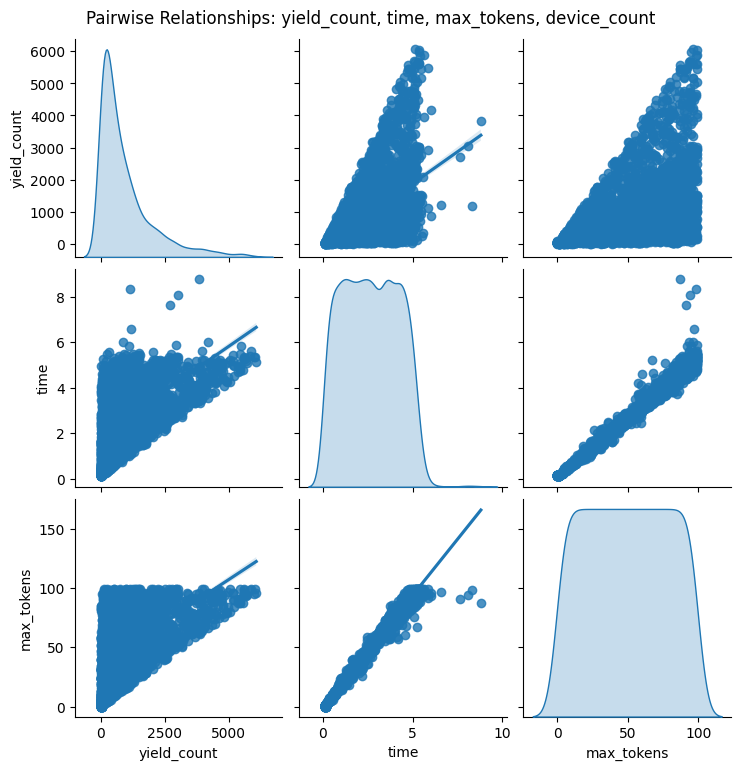

Correlation matrix:
              yield_count      time  max_tokens
yield_count     1.000000  0.555835    0.530123
time            0.555835  1.000000    0.990628
max_tokens      0.530123  0.990628    1.000000


In [14]:
import seaborn as sns

# Select relevant columns
corr_data = data[["yield_count", "time", "max_tokens", ]]# "device_count"]]

# Pairplot to visualize relationships
sns.pairplot(corr_data, kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships: yield_count, time, max_tokens, device_count", y=1.02)
plt.show()

# Display correlation matrix
corr_matrix = corr_data.corr()
print("Correlation matrix:\n", corr_matrix)

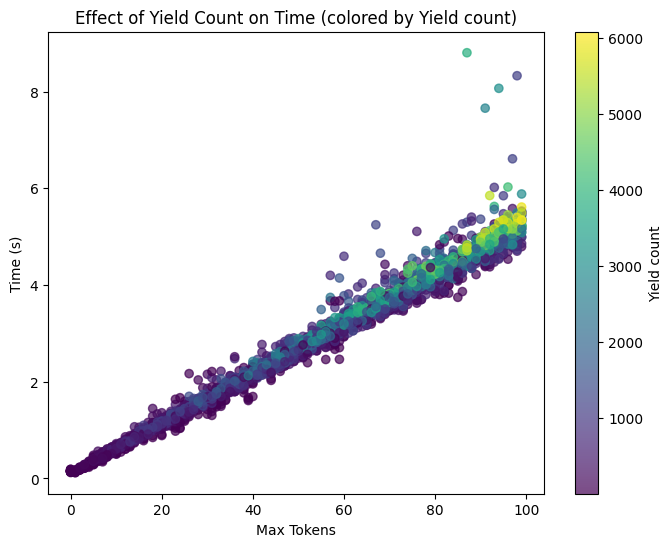

In [15]:
# Scatter plot: yield_count vs time, colored by max_tokens
plt.figure(figsize=(8, 6))
sc = plt.scatter(data["max_tokens"], data["time"], c=data["yield_count"], cmap="viridis", alpha=0.7)
plt.xlabel("Max Tokens")
plt.ylabel("Time (s)")
plt.title("Effect of Yield Count on Time (colored by Yield count)")
cbar = plt.colorbar(sc)
cbar.set_label("Yield count")
plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm

scaler = MinMaxScaler()
df = data.copy()
df["max_tokens_sq"] = df["max_tokens"]**2
X_raw = df[["max_tokens", "max_tokens_sq", "yield_count", "device_count", "time"]]
X_norm = scaler.fit_transform(X_raw)

X1 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens"]]
X2 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq"]]
X3 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq", "yield_count"]]
X4 = pd.DataFrame(X_norm, columns=X_raw.columns)[["max_tokens", "max_tokens_sq", "yield_count", "device_count"]]
y = X_raw["time"]

X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)
X3 = sm.add_constant(X3)
X4 = sm.add_constant(X4)

model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()
model3 = sm.OLS(y, X3).fit()
model4 = sm.OLS(y, X4).fit()

print(model4.summary())
print("F-test p-value for adding device_count:", model4.compare_f_test(model3)[1])
print("F-test p-value for adding yield_count:", model3.compare_f_test(model2)[1])
print("F-test p-value for adding max_tokens_sq:", model2.compare_f_test(model1)[1])

print("R-squared values:")
print("Model 1 (max_tokens):", model1.rsquared)
print("Model 2 (max_tokens + max_tokens_sq):", model2.rsquared)
print("Model 3 (max_tokens + max_tokens_sq + yield_count):", model3.rsquared)
print("Model 4 (max_tokens + max_tokens_sq + yield_count + device_count):", model4.rsquared)


                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 4.379e+04
Date:                Thu, 25 Sep 2025   Prob (F-statistic):               0.00
Time:                        10:14:35   Log-Likelihood:                 634.60
No. Observations:                3000   AIC:                            -1259.
Df Residuals:                    2995   BIC:                            -1229.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1599      0.011     13.948

                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 4.379e+04
Date:                Thu, 25 Sep 2025   Prob (F-statistic):               0.00
Time:                        10:14:35   Log-Likelihood:                 634.60
No. Observations:                3000   AIC:                            -1259.
Df Residuals:                    2995   BIC:                            -1229.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1599      0.011     13.948

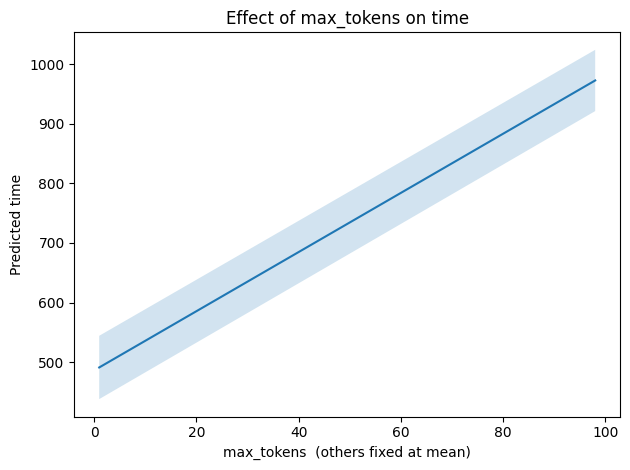

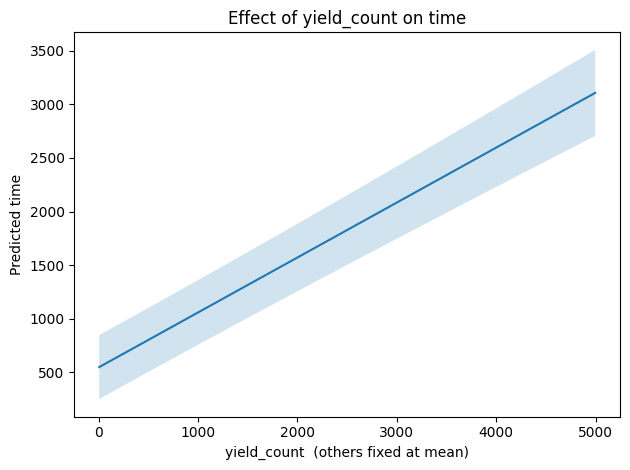

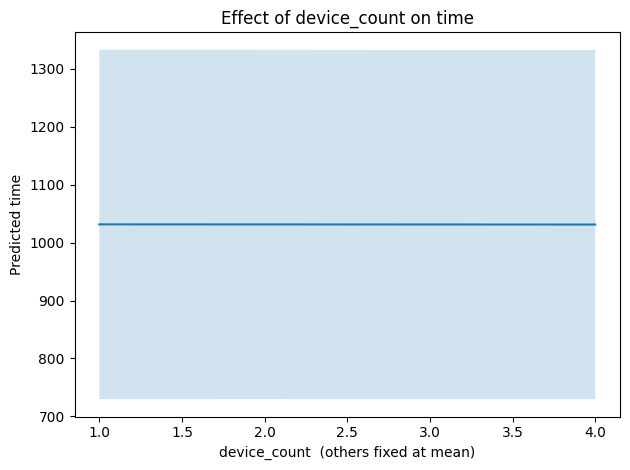

In [17]:
# pip install pandas numpy statsmodels matplotlib
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Assume df already has: time, max_tokens, yield_count
df = data.copy()

# ------------------------------------------------------------
# 1) Add quadratic terms
# ------------------------------------------------------------
df["max_tokens_sq"] = df["max_tokens"]**2

# ------------------------------------------------------------
# 2) Fit quadratic OLS model
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_raw = df[["max_tokens", "yield_count", "max_tokens_sq", "device_count"]]
X_norm = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_norm, columns=X_raw.columns)
X = sm.add_constant(X)
y = df["time"]

quad_model = sm.OLS(y, X).fit()
print(quad_model.summary())

# ------------------------------------------------------------
# 3) Effect plot for max_tokens (quadratic)
# ------------------------------------------------------------
def quadratic_effect_plot(var_name, hold_vars, n=200):
    hold_vals = {k: df[k].mean() for k in hold_vars + ["max_tokens_sq"]}
    vmin, vmax = np.percentile(df[var_name], [1, 99])
    grid = np.linspace(vmin, vmax, n)

    design = pd.DataFrame({
        "const": 1.0,
        "max_tokens": grid if var_name == "max_tokens" else hold_vals["max_tokens"],
        "yield_count": grid if var_name == "yield_count" else hold_vals["yield_count"],
        "max_tokens_sq": (grid if var_name == "max_tokens" else hold_vals["max_tokens_sq"]),
        "device_count": grid if var_name == "device_count" else hold_vals["device_count"],
    })

    pred_res = quad_model.get_prediction(design).summary_frame(alpha=0.05)

    plt.figure()
    plt.plot(grid, pred_res["mean"])
    plt.fill_between(grid, pred_res["mean_ci_lower"], pred_res["mean_ci_upper"], alpha=0.2)
    plt.xlabel(var_name + f"  (others fixed at mean)")
    plt.ylabel("Predicted time")
    plt.title(f"Effect of {var_name} on time")
    plt.tight_layout()
    plt.show()

quadratic_effect_plot("max_tokens", ["yield_count", "device_count"])
quadratic_effect_plot("yield_count", ["max_tokens", "device_count"])
quadratic_effect_plot("device_count", ["max_tokens", "yield_count"])


In [18]:
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression

# Fit a linear regression model for sensitivity analysis
lr = LinearRegression()
lr.fit(X_raw, y)

# Permutation importance (global sensitivity)
result = permutation_importance(lr, X_raw, y, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Display results
importances = pd.Series(result.importances_mean, index=X_raw.columns)
importances = importances.sort_values(ascending=False)
print("Permutation Importance (Global Sensitivity):")
print(importances)

Permutation Importance (Global Sensitivity):
max_tokens       3.997013
yield_count      0.016304
device_count     0.003356
max_tokens_sq    0.001478
dtype: float64


/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-benchmark/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dogac/code/edge-llm-b

In [22]:
data = pd.read_json("../results/bm_stability_auto_regressive.json")
data

,timestamp,time,device_count,prompt_length,max_seq_len,max_tokens,performance_mode,yield_probability,total_generated_tokens,yield_count
0,2025-09-25 13:25:24.262772083,0.187071,1,107,8192,4,False,0,4,2
1,2025-09-25 13:25:27.170965672,0.231521,1,107,8192,4,False,1,4,66
2,2025-09-25 13:25:30.922598600,0.688265,1,107,8192,16,False,0,16,2
3,2025-09-25 13:25:35.093363762,0.746840,1,107,8192,16,False,1,16,258
4,2025-09-25 13:25:43.259488106,2.661029,1,107,8192,64,False,0,64,2
...,...,...,...,...,...,...,...,...,...,...
235,2025-09-25 14:55:57.770580530,0.748865,4,107,8192,16,False,1,16,1032
236,2025-09-25 14:56:23.814498663,2.590217,4,107,8192,64,False,0,64,8
237,2025-09-25 14:56:55.849117041,2.715773,4,107,8192,64,False,1,64,4104
238,2025-09-25 14:58:31.451919079,12.487787,4,107,8192,256,False,0,256,8


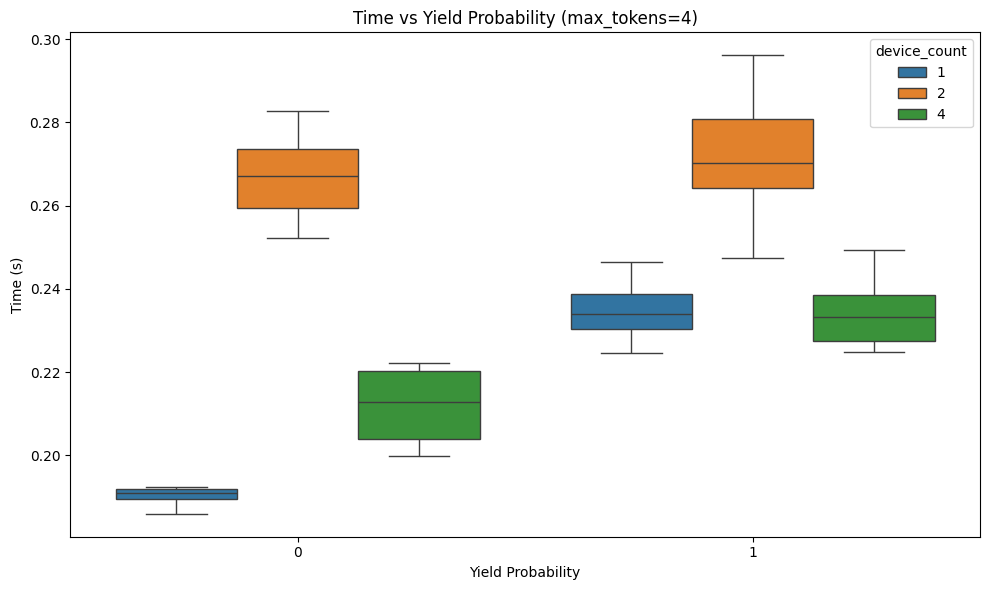

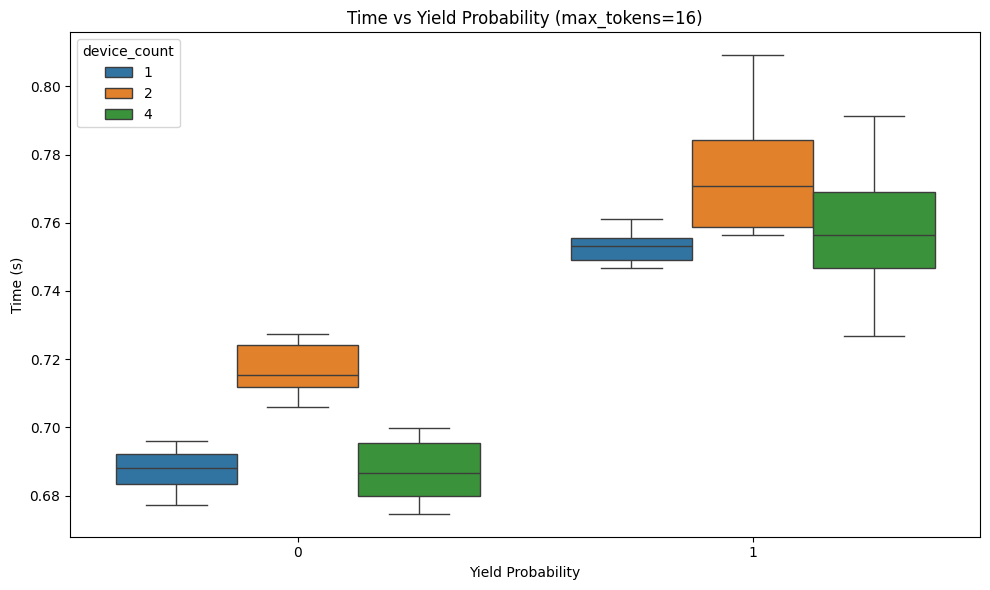

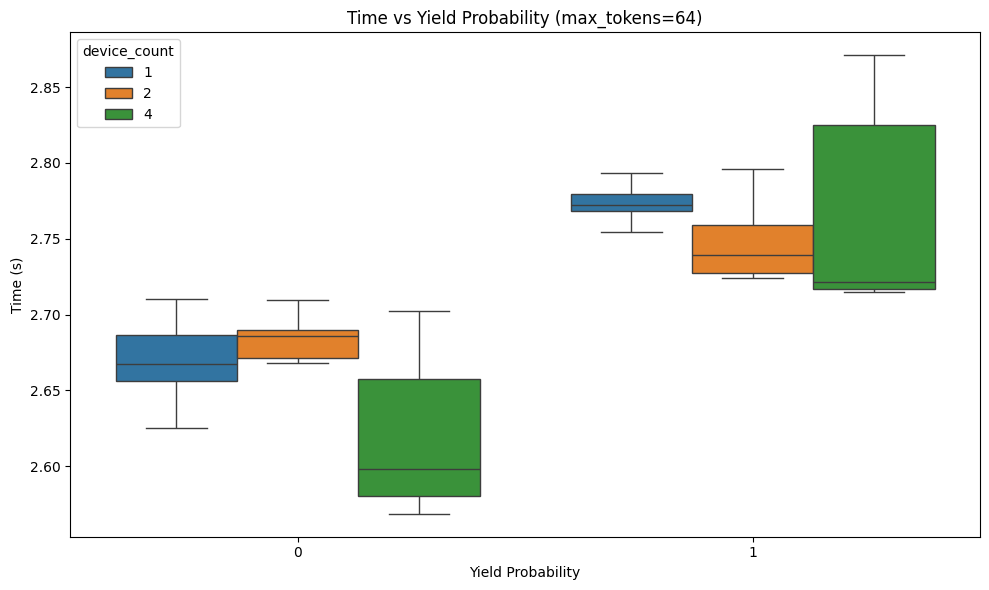

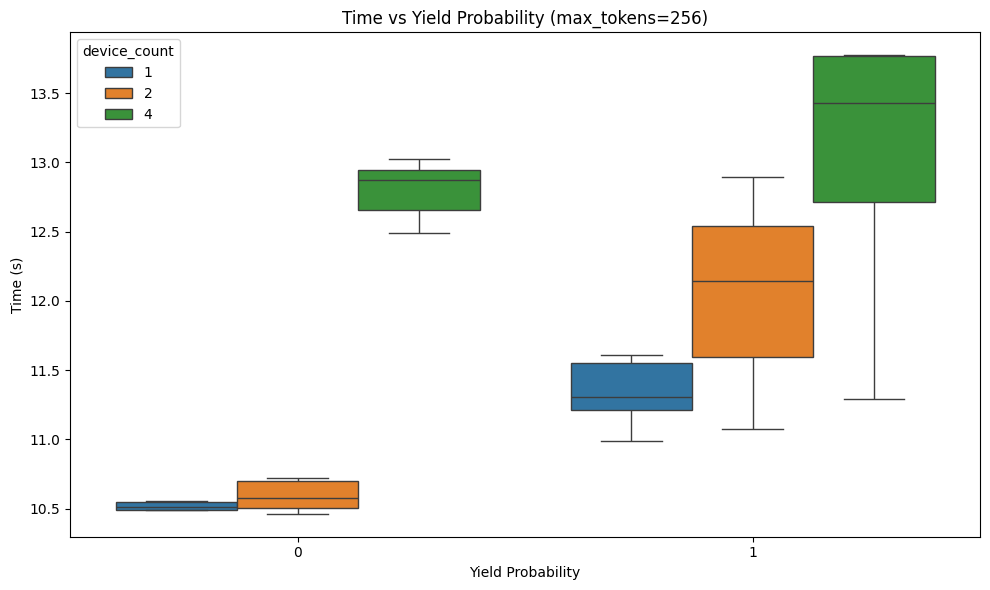

In [44]:
import seaborn as sns

for mt in sorted(data["max_tokens"].unique()):
    plt.figure(figsize=(10, 6))
    subset = data[data["max_tokens"] == mt]
    sns.boxplot(
        data=subset,
        x="yield_probability",
        y="time",
        hue="device_count",
        palette="tab10",
        showfliers=False
    )
    plt.title(f"Time vs Yield Probability (max_tokens={mt})")
    plt.xlabel("Yield Probability")
    plt.ylabel("Time (s)")
    plt.legend(title="device_count")
    plt.tight_layout()
    plt.show()


In [40]:
data[(data["device_count"]==1) & (data["max_tokens"]==4) & (data["yield_probability"]==0.0)]["time"].mean()

np.float64(0.19068734189495382)